# Step 2: Exploratory Data Analysis

**Goal:** understand what drives weekly store sales before building any forecast.

**Questions:**
1. What does chain-wide demand look like over time (trend, seasonality)?
2. How do sales vary by day of week and month?
3. Do promotions, holidays, store type, and competition move sales?
4. How skewed is the sales distribution?
5. Which stores should be the deep-dive sample for Steps 4–5?

Data comes from the `RetailForecast` SQL Server database built in Step 1.

In [1]:
import os
import warnings
import pyodbc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=UserWarning)  # pandas warns about raw pyodbc connections
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", "{:,.0f}".format)

FIG_DIR = "../figures"
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs("../data/processed", exist_ok=True)

def save(name):
    plt.tight_layout()
    plt.savefig(f"{FIG_DIR}/{name}.png", dpi=150)

## 1. Connect to SQL Server

In [2]:
# Use the newest installed SQL Server ODBC driver
drivers = [d for d in pyodbc.drivers() if "ODBC Driver" in d and "SQL Server" in d]
print("Available drivers:", drivers)
DRIVER = sorted(drivers)[-1]

conn = pyodbc.connect(
    f"DRIVER={{{DRIVER}}};SERVER=localhost;DATABASE=RetailForecast;"
    "Trusted_Connection=yes;TrustServerCertificate=yes;"
)
print("Connected with", DRIVER)

Available drivers: ['ODBC Driver 17 for SQL Server', 'ODBC Driver 18 for SQL Server']
Connected with ODBC Driver 18 for SQL Server


## 2. Load data

In [3]:
# Daily data: open days with sales only (closures and the 54 zero-sales errors excluded, per Step 1)
daily = pd.read_sql("""
    SELECT d.Store, d.DayOfWeek, d.SalesDate, d.Sales, d.Customers, d.Promo,
           d.StateHoliday, d.SchoolHoliday,
           s.StoreType, s.Assortment, s.CompetitionDistance, s.Promo2
    FROM daily_sales d
    JOIN stores s ON d.Store = s.Store
    WHERE d.IsOpen = 1 AND d.Sales > 0
""", conn, parse_dates=["SalesDate"])

weekly = pd.read_sql("SELECT * FROM weekly_store_sales", conn, parse_dates=["WeekStart"])

# Stores with a full, unbroken history (934 stores; excludes the Jul-Dec 2014 gap)
complete_stores = pd.read_sql(
    "SELECT Store FROM daily_sales GROUP BY Store HAVING COUNT(*) = 942", conn
)["Store"]

print(f"Daily rows (open, sales > 0): {len(daily):,}")
print(f"Weekly rows: {len(weekly):,}")
print(f"Complete stores: {len(complete_stores):,}")

Daily rows (open, sales > 0): 844,338
Weekly rows: 146,025
Complete stores: 934


## 3. Chain-wide weekly sales: trend and seasonality

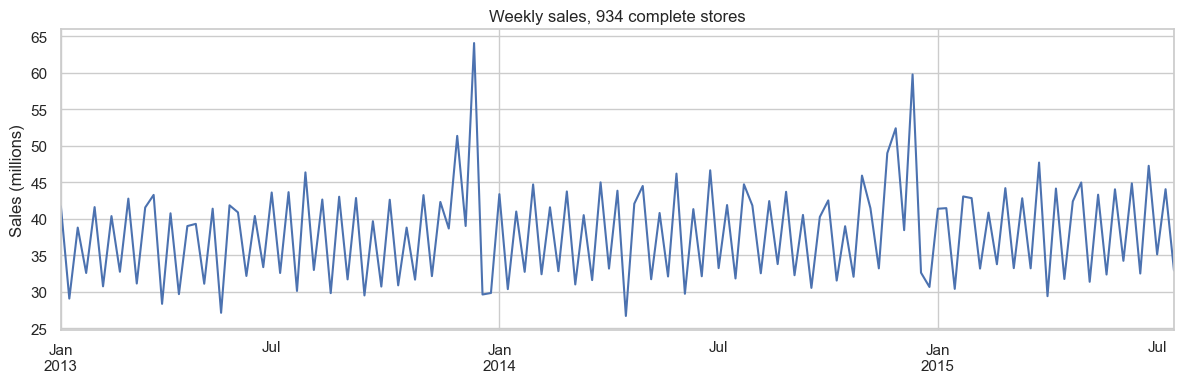

In [4]:
# Full weeks only, complete stores only, so the gap and partial weeks don't create fake dips
chain = (weekly[(weekly["DaysInData"] == 7) & (weekly["Store"].isin(complete_stores))]
         .groupby("WeekStart")["WeeklySales"].sum() / 1e6)

fig, ax = plt.subplots(figsize=(12, 4))
chain.plot(ax=ax)
ax.set_title("Weekly sales, 934 complete stores")
ax.set_ylabel("Sales (millions)")
ax.set_xlabel("")
save("01_chain_weekly_sales")
plt.show()

In [7]:
promo_weeks = (weekly[(weekly["DaysInData"] == 7) & (weekly["Store"].isin(complete_stores))]
               .groupby("WeekStart")["PromoDays"].mean())
print(pd.concat([chain, promo_weeks], axis=1).groupby("PromoDays")["WeeklySales"].mean())

PromoDays
0   32
5   43
Name: WeeklySales, dtype: float64


**Finding:** Chain sales show no long-term trend across 2013–2015. Demand follows the biweekly promotion calendar: promo weeks average 43M vs. 32M for non-promo weeks (+34%, observed difference, tested formally in Step 6). Sales peak about 50% above normal in the weeks before Christmas, then drop sharply after the holiday.

## 4. Day-of-week and monthly patterns

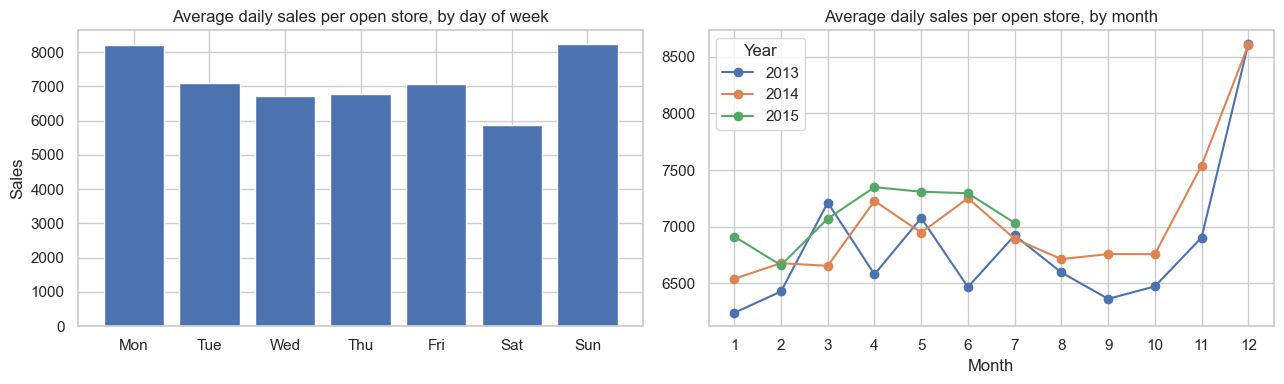

Share of open store-days by weekday:
DayOfWeek
1   16
2   17
3   17
4   16
5   16
6   17
7    0
Name: proportion, dtype: float64


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

dow_labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
dow = daily.groupby("DayOfWeek")["Sales"].mean()
axes[0].bar([dow_labels[i - 1] for i in dow.index], dow.values)
axes[0].set_title("Average daily sales per open store, by day of week")
axes[0].set_ylabel("Sales")

monthly = (daily.assign(Year=daily["SalesDate"].dt.year, Month=daily["SalesDate"].dt.month)
                .groupby(["Year", "Month"])["Sales"].mean().unstack(0))
monthly.plot(ax=axes[1], marker="o")
axes[1].set_title("Average daily sales per open store, by month")
axes[1].set_xticks(range(1, 13))
axes[1].set_xlabel("Month")

save("02_dow_and_month")
plt.show()

print("Share of open store-days by weekday:")
print((daily["DayOfWeek"].value_counts(normalize=True).sort_index() * 100).round(1))

**Finding:** Monday is the strongest regular trading day (~8,200 per store) and Saturday the weakest (~5,850, about 30% lower). Sunday's high average is misleading: fewer than 1% of store-days are Sunday openings, likely special locations. December is the peak month, 25–30% above a typical month, and January the weakest. Per-store sales in 2015 run slightly above prior years, suggesting mild growth.

## 5. Promotions (first look)

Promotions only run Monday to Friday, so a plain promo vs. no-promo average is biased by weekday.
Comparing within each weekday removes that bias. The formal significance test is in Step 6.

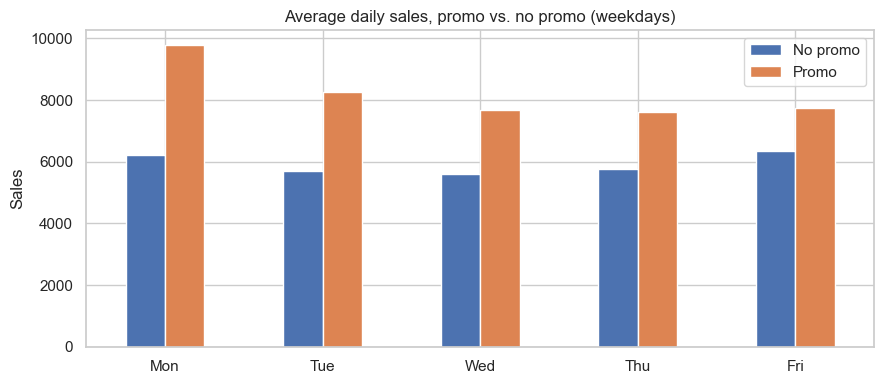

,No promo,Promo,Lift %
Mon,"6,223","9,773",57
Tue,"5,716","8,278",45
Wed,"5,618","7,686",37
Thu,"5,751","7,599",32
Fri,"6,344","7,744",22


In [9]:
promo_by_dow = (daily[daily["DayOfWeek"] <= 5]
                .groupby(["DayOfWeek", "Promo"])["Sales"].mean().unstack())
promo_by_dow.columns = ["No promo", "Promo"]
promo_by_dow["Lift %"] = (promo_by_dow["Promo"] / promo_by_dow["No promo"] - 1) * 100
promo_by_dow.index = dow_labels[:5]

ax = promo_by_dow[["No promo", "Promo"]].plot(kind="bar", figsize=(9, 4), rot=0)
ax.set_title("Average daily sales, promo vs. no promo (weekdays)")
ax.set_ylabel("Sales")
save("03_promo_by_weekday")
plt.show()

promo_by_dow.round(1)

**Finding:** Promotions raise average daily sales on every weekday, but the effect is front-loaded: the lift is largest on Monday (+57%) and declines steadily to Friday (+22%). Stores therefore need extra stock at the start of promo weeks. Because promotions always start on Monday, part of Monday's overall strength is promotion-driven. Whether this is new demand or demand shifted from non-promo weeks is tested in Step 6.

## 6. Holidays

In [12]:
holiday_map = {"0": "None", "a": "Public", "b": "Easter", "c": "Christmas"}
hol = (daily.assign(Holiday=daily["StateHoliday"].map(holiday_map))
            .groupby("Holiday")["Sales"].agg(["mean", "count"]))
print("Open days by state holiday type:")
display(hol)

school = daily.groupby("SchoolHoliday")["Sales"].mean()
print(f"School holiday lift: {(school.loc[True] / school.loc[False] - 1) * 100:.1f}%")

# Pre-Christmas demand: last two weeks before Christmas vs. the rest of the year
pre_xmas = daily["SalesDate"].dt.month.eq(12) & daily["SalesDate"].dt.day.between(11, 24)
print(f"Dec 11-24 vs. rest of year: {(daily.loc[pre_xmas, 'Sales'].mean() / daily.loc[~pre_xmas, 'Sales'].mean() - 1) * 100:.1f}%")

Open days by state holiday type:


,mean,count
Holiday,,
Christmas,"9,744",71
Easter,"9,888",145
None,"6,954",843428
Public,"8,487",694


School holiday lift: 4.4%
Dec 11-24 vs. rest of year: 36.4%


**Finding:** Nearly all stores close on state holidays; only about 0.1% of open store-days fall on one, so a holiday's main forecasting impact is lost trading days in that week. School holidays add a modest +4.4%. The strongest seasonal effect is the pre-Christmas period: sales on Dec 11–24 run 36% above the rest of the year.

## 7. Store type, assortment, and competition

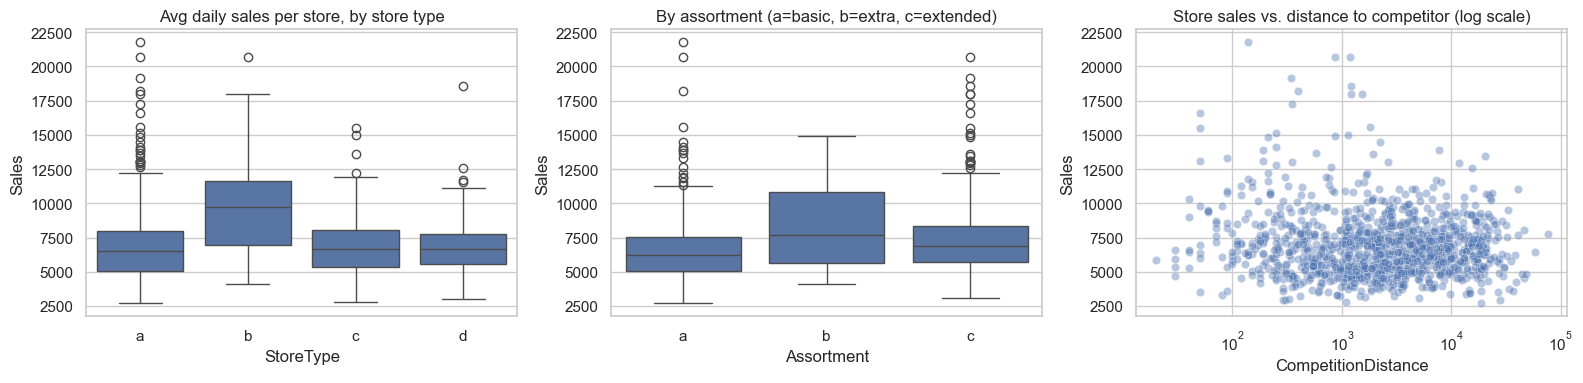

Stores per type:
StoreType
a    602
b     17
c    148
d    348
Name: count, dtype: int64
Correlation, log(competition distance) vs. avg sales: -0.10


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

store_avg = (daily.groupby(["Store", "StoreType", "Assortment"])
                 .agg(Sales=("Sales", "mean"), CompetitionDistance=("CompetitionDistance", "first"))
                 .reset_index())

sns.boxplot(data=store_avg, x="StoreType", y="Sales", order=list("abcd"), ax=axes[0])
axes[0].set_title("Avg daily sales per store, by store type")

sns.boxplot(data=store_avg, x="Assortment", y="Sales", order=list("abc"), ax=axes[1])
axes[1].set_title("By assortment (a=basic, b=extra, c=extended)")

sns.scatterplot(data=store_avg, x="CompetitionDistance", y="Sales", alpha=0.4, ax=axes[2])
axes[2].set_xscale("log")
axes[2].set_title("Store sales vs. distance to competitor (log scale)")

save("04_store_attributes")
plt.show()

print("Stores per type:")
print(store_avg["StoreType"].value_counts().sort_index())
print(f"Correlation, log(competition distance) vs. avg sales: "
      f"{np.log(store_avg['CompetitionDistance']).corr(store_avg['Sales']):.2f}")

**Finding:** Store type b sells far more than the other types (median ~9,800 vs. ~6,700 per day), but it is only 17 stores, likely special high-traffic locations that also account for most Sunday and holiday openings. Types a, c, and d perform similarly, and extended assortments sell modestly more than basic ones. Competitor distance has almost no relationship with sales (r = -0.10); the slight tendency for stores near competitors to sell more likely reflects busy urban locations rather than a competition effect.

## 8. Sales distribution

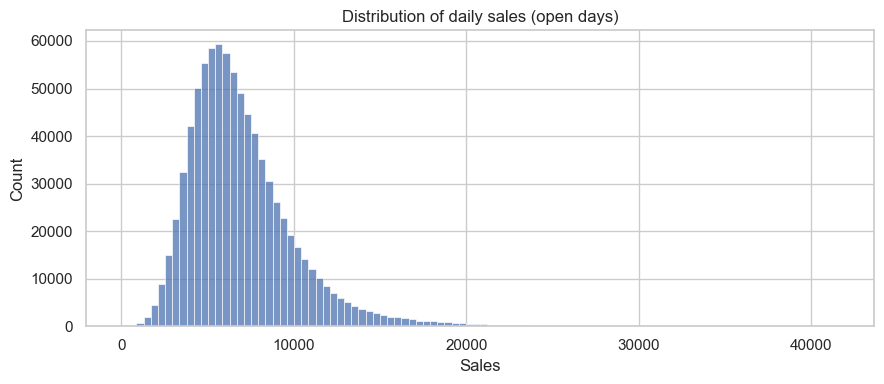

Mean: 6,956   Median: 6,369   Skewness: 1.59


In [14]:
fig, ax = plt.subplots(figsize=(9, 4))
sns.histplot(daily["Sales"], bins=100, ax=ax)
ax.set_title("Distribution of daily sales (open days)")
save("05_sales_distribution")
plt.show()

print(f"Mean: {daily['Sales'].mean():,.0f}   Median: {daily['Sales'].median():,.0f}   "
      f"Skewness: {daily['Sales'].skew():.2f}")

**Finding:** Daily sales are right-skewed (skewness 1.59): most open days fall between 3,000 and 10,000, with a long tail up to ~41,000 driven by peak periods and high-traffic stores. The mean (6,956) sits about 9% above the median (6,369). This supports keeping the Step 1 outliers as genuine peaks, modeling log-transformed sales, and evaluating accuracy with percentage metrics (MAPE/WAPE) rather than RMSE, which the largest stores would dominate.

## 9. Choose the deep-dive sample stores

For Steps 4–5, pick one typical store per store type: a complete store whose average weekly
sales are closest to the median for its type.

In [15]:
full_weeks = weekly[(weekly["DaysInData"] == 7) & (weekly["Store"].isin(complete_stores))]
store_weekly = full_weeks.groupby(["Store", "StoreType"])["WeeklySales"].mean().reset_index()

sample = (store_weekly
          .assign(dist=lambda df: (df["WeeklySales"]
                                   - df.groupby("StoreType")["WeeklySales"].transform("median")).abs())
          .sort_values("dist")
          .groupby("StoreType").head(1)
          .sort_values("StoreType")
          .drop(columns="dist"))

sample.to_csv("../data/processed/sample_stores.csv", index=False)
sample

,Store,StoreType,WeeklySales
607,732,a,"38,042"
355,423,b,"75,841"
422,504,c,"38,865"
291,352,d,"38,977"


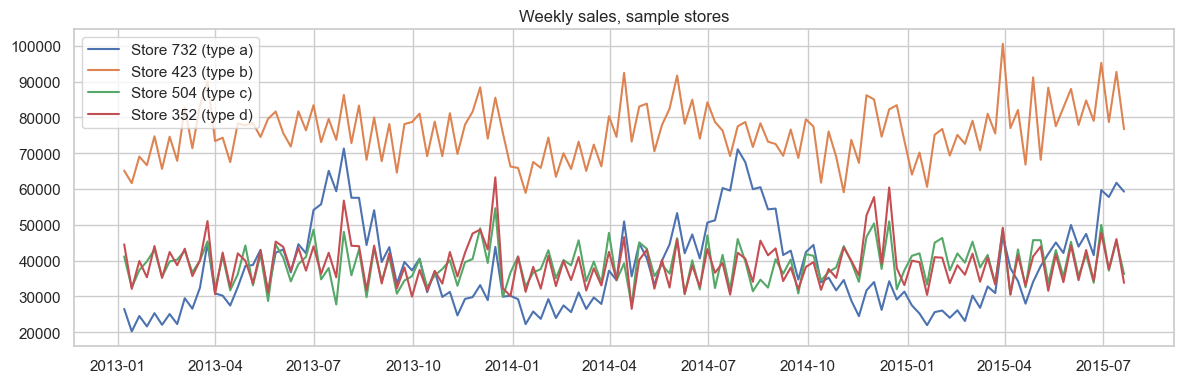

In [16]:
fig, ax = plt.subplots(figsize=(12, 4))
for _, row in sample.iterrows():
    s = full_weeks[full_weeks["Store"] == row["Store"]].set_index("WeekStart")["WeeklySales"]
    ax.plot(s.index, s.values, label=f"Store {row['Store']} (type {row['StoreType']})")
ax.set_title("Weekly sales, sample stores")
ax.legend()
save("06_sample_stores")
plt.show()

**Finding:** The four sample stores cover the main demand shapes. Stores 504 (type c) and 352 (type d) follow the chain pattern of biweekly promotion swings and a December peak. Store 423 (type b) sells about twice as much with a weaker December peak. Store 732 (type a) peaks in summer (Jul–Aug) and has no December spike, suggesting a seasonal or tourist location. Seasonality therefore differs by store, which motivates clustering stores by demand shape in Step 3.

## Summary of findings

- **Promotions are the biggest driver:** promo weeks average 43M vs. 32M chain-wide (+34%), and the lift is front-loaded (Monday +57% → Friday +22%).
- **Strong December seasonality:** sales on Dec 11–24 run 36% above the rest of the year, followed by a sharp post-holiday drop. No meaningful long-term trend, with mild per-store growth in 2015.
- **Weekly rhythm:** Monday is the strongest regular day, Saturday the weakest; almost all stores close Sundays and state holidays.
- **Stores differ in shape, not just size:** type b stores sell about 2x more, and some stores (e.g., 732) peak in summer instead of December.
- **Competitor distance barely matters** (r = -0.10).
- **Sales are right-skewed** (skewness 1.59), so models will use log sales and percentage error metrics.

In [ ]:
conn.close()